In [1]:
import numpy as np
import pandas as pd
import pickle

import sklearn
import sklearn.preprocessing
import sklearn.model_selection

import torch
import torch.nn as nn
import torch.nn.functional as F

from tqdm import tqdm
import time

from matplotlib import pyplot as plt
import os
from copy import deepcopy

from models import *

In [2]:
with open('data/current.pkl', 'rb') as file:
    df_current = pickle.load(file)

with open('data/parameters.pkl', 'rb') as file:
    df_params = pickle.load(file)

In [3]:
df_params = df_params.rename(columns={"membrane": "diaphragm", "WW": "circuit function", "nominal width": "nominal width in mm", "voltage": "voltage in V", "pvor": "p_supply in bar", "prueck": "p_back in bar"})
df_params['nominal width in mm'] = df_params['nominal width in mm'].str.replace(',', '.').astype('float')
df_params['voltage in V'] = df_params['voltage in V'].astype('float')
df_params['p_supply in bar'] = df_params['p_supply in bar'].astype('float')
df_params['p_back in bar'] = df_params['p_back in bar'].astype('float')
df_params['ID'] = df_params['ID'].astype('int')

In [4]:
X = df_current.values
y = df_params['diaphragm'].copy()

In [5]:
enc = sklearn.preprocessing.OneHotEncoder(categories=[['AA', 'FF', 'CC']], sparse=False)
y_ohe = enc.fit_transform(y.values.reshape(-1, 1))
y_ohe

array([[0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       ...,
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.]])

In [6]:
# Random Train-test split
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y_ohe, test_size=0.2, random_state=42)#, stratify=y_ohe)

In [7]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")

In [8]:
cat_weights = torch.tensor([1.,4.,1.],dtype=torch.float32, device=device)

In [9]:
model = PDEInspiredModel(ts_model=ValvePositionPrediction,model_channels=5)
model = model.to(device)
model(torch.tensor(X_train[:1],dtype=torch.float32, device=device))

tensor([[0.3349, 0.3117, 0.3533]], grad_fn=<SoftmaxBackward0>)

In [10]:
X_fit, X_val, y_fit, y_val = sklearn.model_selection.train_test_split(X_train, y_train, test_size=0.30, random_state=123)#, stratify=y_ohe)

history = model.fit(X_fit, y_fit, X_val, y_val, cat_weights=cat_weights)

parameter count: 188
3.0467218081753344e-08
epoch 0, loss=1.5584455132484436, val. loss=1.4403420686721802, val. acc.=0.14450867474079132, time: 288ms
0.0
epoch 1, loss=1.5647141933441162, val. loss=1.4461052417755127, val. acc.=0.1059730276465416, time: 268ms
2.7641838151737375e-08
epoch 2, loss=1.559375286102295, val. loss=1.4489306211471558, val. acc.=0.1059730276465416, time: 268ms
1.623299183961535e-08
epoch 3, loss=1.5349745154380798, val. loss=1.446241021156311, val. acc.=0.1059730276465416, time: 265ms
8.617867308657878e-09
epoch 4, loss=1.5230839252471924, val. loss=1.442863941192627, val. acc.=0.1059730276465416, time: 245ms
0.0
epoch 5, loss=1.5121138095855713, val. loss=1.4376187324523926, val. acc.=0.1059730276465416, time: 240ms
4.154100619047085e-09
epoch 6, loss=1.5100533366203308, val. loss=1.429613709449768, val. acc.=0.1059730276465416, time: 262ms
2.887255767802799e-09
epoch 7, loss=1.5010372400283813, val. loss=1.4191975593566895, val. acc.=0.1059730276465416, time

0.0011822085798485205
epoch 65, loss=0.2928337901830673, val. loss=0.32895344495773315, val. acc.=0.913294792175293, time: 241ms
0.0
epoch 66, loss=0.3056901544332504, val. loss=0.2802395820617676, val. acc.=0.9190751314163208, time: 266ms
0.00039884657599031925
epoch 67, loss=0.2882961928844452, val. loss=0.2704828679561615, val. acc.=0.9306358098983765, time: 286ms
0.0004655600459955167
epoch 68, loss=0.2747751548886299, val. loss=0.262474000453949, val. acc.=0.9287090301513672, time: 238ms
0.0002985245082527399
epoch 69, loss=0.2665759176015854, val. loss=0.2899530529975891, val. acc.=0.9248554706573486, time: 229ms
0.00019161729142069817
epoch 70, loss=0.26335685700178146, val. loss=0.2664598524570465, val. acc.=0.913294792175293, time: 235ms
0.00012734140909742564
epoch 71, loss=0.24507469683885574, val. loss=0.27304625511169434, val. acc.=0.9344894289970398, time: 231ms
3.468590512056835e-05
epoch 72, loss=0.268653005361557, val. loss=0.2516409456729889, val. acc.=0.9325626492500

0.0007526494446210563
epoch 129, loss=0.14350640773773193, val. loss=0.1627953052520752, val. acc.=0.9537572264671326, time: 228ms
0.002937329700216651
epoch 130, loss=0.14461766183376312, val. loss=0.15412543714046478, val. acc.=0.9614643454551697, time: 227ms
0.0017318922909907997
epoch 131, loss=0.14503474533557892, val. loss=0.14989961683750153, val. acc.=0.963391125202179, time: 229ms
0.0008353483426617458
epoch 132, loss=0.13439366966485977, val. loss=0.15027140080928802, val. acc.=0.963391125202179, time: 237ms
0.0008806580663076602
epoch 133, loss=0.1496385857462883, val. loss=0.14772173762321472, val. acc.=0.9653179049491882, time: 227ms
0.0030185654759407043
epoch 134, loss=0.12373403459787369, val. loss=0.14630185067653656, val. acc.=0.9653179049491882, time: 237ms
0.000727998383808881
epoch 135, loss=0.1363910548388958, val. loss=0.1444351077079773, val. acc.=0.9653179049491882, time: 233ms
5.4368247219827026e-05
epoch 136, loss=0.14048445597290993, val. loss=0.143581509590

0.0
epoch 192, loss=0.107576634734869, val. loss=0.12413307279348373, val. acc.=0.9672446846961975, time: 228ms
0.0006751358741894364
epoch 193, loss=0.11169606447219849, val. loss=0.12812785804271698, val. acc.=0.963391125202179, time: 237ms
0.00037433608667925
epoch 194, loss=0.11639800667762756, val. loss=0.12387006729841232, val. acc.=0.9653179049491882, time: 238ms
0.008809973020106554
epoch 195, loss=0.11664323136210442, val. loss=0.12310879677534103, val. acc.=0.9653179049491882, time: 239ms
0.0024138688531820662
epoch 196, loss=0.11839652806520462, val. loss=0.14254045486450195, val. acc.=0.9595375657081604, time: 233ms
0.006666407207376324
epoch 197, loss=0.13167955726385117, val. loss=0.17991533875465393, val. acc.=0.9614643454551697, time: 235ms
0.0
epoch 198, loss=0.1175859123468399, val. loss=0.1331380158662796, val. acc.=0.9672446846961975, time: 229ms
0.00020296770526329055
epoch 199, loss=0.11593182012438774, val. loss=0.13568106293678284, val. acc.=0.9672446846961975, 

0.0062526860274374485
epoch 256, loss=0.08939951658248901, val. loss=0.11479712277650833, val. acc.=0.9710982441902161, time: 236ms
0.002750415005721152
epoch 257, loss=0.08753146603703499, val. loss=0.12761101126670837, val. acc.=0.9672446846961975, time: 230ms
0.005391280632466078
epoch 258, loss=0.10674140602350235, val. loss=0.11315077543258667, val. acc.=0.9730250239372253, time: 236ms
2.6068359147757292e-05
epoch 259, loss=0.09817112982273102, val. loss=0.12005465477705002, val. acc.=0.9672446846961975, time: 260ms
0.0015299722144845873
epoch 260, loss=0.10633543878793716, val. loss=0.12393569201231003, val. acc.=0.963391125202179, time: 227ms
0.0010872279526665807
epoch 261, loss=0.08067794516682625, val. loss=0.10828635096549988, val. acc.=0.9749518036842346, time: 224ms
0.0028680769028142095
epoch 262, loss=0.093672264367342, val. loss=0.11221703141927719, val. acc.=0.9749518036842346, time: 234ms
0.0016662506386637688
epoch 263, loss=0.09445300325751305, val. loss=0.121523521

...

0.027887804433703423
epoch 9734, loss=0.04928925447165966, val. loss=0.06859782338142395, val. acc.=0.9865125417709351, time: 270ms
0.051661983132362366
epoch 9735, loss=0.03588528744876385, val. loss=0.06777980178594589, val. acc.=0.9865125417709351, time: 266ms
0.07589958235621452
epoch 9736, loss=0.042058803141117096, val. loss=0.06832820177078247, val. acc.=0.9865125417709351, time: 272ms
0.17957766354084015
epoch 9737, loss=0.04448760114610195, val. loss=0.06920649856328964, val. acc.=0.9865125417709351, time: 268ms
0.02436823584139347
epoch 9738, loss=0.03711402602493763, val. loss=0.06981940567493439, val. acc.=0.9865125417709351, time: 262ms
0.26025697588920593
epoch 9739, loss=0.04735827259719372, val. loss=0.06801310181617737, val. acc.=0.9865125417709351, time: 267ms
0.03413257747888565
epoch 9740, loss=0.04505538288503885, val. loss=0.06799212098121643, val. acc.=0.9865125417709351, time: 266ms
0.1018543392419815
epoch 9741, loss=0.037520283833146095, val. loss=0.0693231970

0.3735238015651703
epoch 9797, loss=0.041751207783818245, val. loss=0.06889350712299347, val. acc.=0.9865125417709351, time: 265ms
0.3080054000020027
epoch 9798, loss=0.03872706089168787, val. loss=0.06919494271278381, val. acc.=0.9865125417709351, time: 271ms
0.1067730002105236
epoch 9799, loss=0.04631468281149864, val. loss=0.06955663114786148, val. acc.=0.9845857620239258, time: 266ms
0.13839454017579556
epoch 9800, loss=0.0409857090562582, val. loss=0.0675526037812233, val. acc.=0.9865125417709351, time: 270ms
0.00863664411008358
epoch 9801, loss=0.04810227081179619, val. loss=0.06732406467199326, val. acc.=0.9865125417709351, time: 273ms
0.06711364164948463
epoch 9802, loss=0.041582271456718445, val. loss=0.06859952956438065, val. acc.=0.9865125417709351, time: 256ms
0.009366961196064949
epoch 9803, loss=0.0418008454144001, val. loss=0.06923829764127731, val. acc.=0.9865125417709351, time: 268ms
0.1581234447658062
epoch 9804, loss=0.04364617820829153, val. loss=0.06936110556125641

0.10675078630447388
epoch 9860, loss=0.04057160206139088, val. loss=0.0734710544347763, val. acc.=0.9865125417709351, time: 281ms
0.0
epoch 9861, loss=0.047572302632033825, val. loss=0.07156196981668472, val. acc.=0.9865125417709351, time: 270ms
0.3155069798231125
epoch 9862, loss=0.0456402525305748, val. loss=0.07166793942451477, val. acc.=0.9865125417709351, time: 260ms
0.0357673317193985
epoch 9863, loss=0.04175720736384392, val. loss=0.07280351221561432, val. acc.=0.9845857620239258, time: 270ms
0.14669163525104523
epoch 9864, loss=0.04622181877493858, val. loss=0.0712215006351471, val. acc.=0.9865125417709351, time: 260ms
0.035129692405462265
epoch 9865, loss=0.046162812039256096, val. loss=0.06962006539106369, val. acc.=0.9865125417709351, time: 266ms
0.0
epoch 9866, loss=0.04897480644285679, val. loss=0.06975884735584259, val. acc.=0.9865125417709351, time: 283ms
0.09861423820257187
epoch 9867, loss=0.04527616314589977, val. loss=0.07252764701843262, val. acc.=0.9845857620239258

0.050431014969944954
epoch 9924, loss=0.03264506720006466, val. loss=0.07308052480220795, val. acc.=0.9865125417709351, time: 268ms
0.054821792989969254
epoch 9925, loss=0.04703407548367977, val. loss=0.071662537753582, val. acc.=0.9865125417709351, time: 266ms
0.039244310930371284
epoch 9926, loss=0.03956993669271469, val. loss=0.07814475893974304, val. acc.=0.9807322025299072, time: 279ms
0.17784421890974045
epoch 9927, loss=0.04464245028793812, val. loss=0.0721413716673851, val. acc.=0.9845857620239258, time: 271ms
0.018526745960116386
epoch 9928, loss=0.04031105246394873, val. loss=0.06811953336000443, val. acc.=0.9865125417709351, time: 290ms
0.3009338453412056
epoch 9929, loss=0.046778712421655655, val. loss=0.06770387291908264, val. acc.=0.9865125417709351, time: 388ms
0.024364884942770004
epoch 9930, loss=0.04448029212653637, val. loss=0.07135798037052155, val. acc.=0.9826589822769165, time: 275ms
0.09854604490101337
epoch 9931, loss=0.045485276728868484, val. loss=0.0718257799

0.16231576725840569
epoch 9987, loss=0.04658925533294678, val. loss=0.07375630736351013, val. acc.=0.9865125417709351, time: 253ms
0.0425153486430645
epoch 9988, loss=0.04594470001757145, val. loss=0.07162030786275864, val. acc.=0.9865125417709351, time: 266ms
0.11424130201339722
epoch 9989, loss=0.041558410972356796, val. loss=0.0739031508564949, val. acc.=0.9826589822769165, time: 262ms
0.19794063828885555
epoch 9990, loss=0.043965959921479225, val. loss=0.0740491971373558, val. acc.=0.978805422782898, time: 258ms
0.1295359507203102
epoch 9991, loss=0.03694151248782873, val. loss=0.06841526925563812, val. acc.=0.9865125417709351, time: 260ms
0.009753293357789516
epoch 9992, loss=0.0431807991117239, val. loss=0.06846533715724945, val. acc.=0.9865125417709351, time: 256ms
0.15259495377540588
epoch 9993, loss=0.04479129612445831, val. loss=0.07046961784362793, val. acc.=0.9845857620239258, time: 260ms
0.08198308199644089
epoch 9994, loss=0.041379391215741634, val. loss=0.076143987476825

In [11]:
model.load_state_dict(torch.load(('./pde_model.pt')))

<All keys matched successfully>

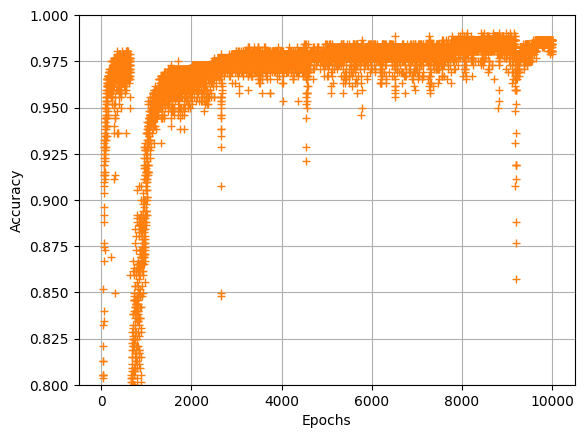

In [12]:
# acc = history.history['accuracy']
val_acc = np.array(history)[:,2]
epochs = range(1, len(val_acc) + 1)

# plt.plot(epochs, acc, 'b+')
plt.plot(epochs, val_acc, '+',color='tab:orange')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.ylim((0.8,1))
plt.grid()
plt.show()

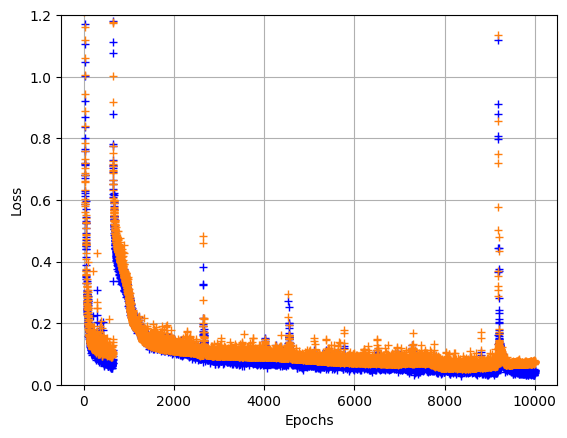

In [13]:
loss_values = np.array(history)[:,0]
val_loss_values = np.array(history)[:,1]
epochs = range(1, len(loss_values) + 1)

plt.plot(epochs, loss_values, 'b+')
plt.plot(epochs, val_loss_values, '+',color='tab:orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.ylim((0.,1.2))
plt.grid()
plt.show()

In [14]:
y_cv = model(torch.tensor(X_train, dtype=torch.float32)).detach().numpy()

In [15]:
new = np.zeros(y_cv.shape)
for i, j in enumerate(y_cv):
    new[i][np.argmax(j)] = 1

y_cv_class = new.astype('int')
y_cv_class

array([[1, 0, 0],
       [0, 0, 1],
       [1, 0, 0],
       ...,
       [1, 0, 0],
       [0, 1, 0],
       [1, 0, 0]])

In [16]:
# Calculate scores
r2_score_train = sklearn.metrics.r2_score(y_train, y_cv_class)
ev_score_train = sklearn.metrics.explained_variance_score(y_train, y_cv_class)
mse_train = sklearn.metrics.mean_squared_error(y_train, y_cv_class)
acc_score_train = sklearn.metrics.accuracy_score(y_train, y_cv_class)
precision_score_train_None = sklearn.metrics.precision_score(y_train, y_cv_class, average=None)
recall_score_train_None = sklearn.metrics.recall_score(y_train, y_cv_class, average=None)
precision_score_train_macro = sklearn.metrics.precision_score(y_train, y_cv_class, average='macro')
recall_score_train_macro= sklearn.metrics.recall_score(y_train, y_cv_class, average='macro')

print("R2 Score: {:.4f}".format(r2_score_train))
print("Explained variance score: {:.4f}".format(ev_score_train))
print("Mean squared error: {:.4f}".format(mse_train))
print("Accuracy Score: {:.4f}".format(acc_score_train))
print(f"Precision: {np.array2string(precision_score_train_None, precision=4, floatmode='fixed')}")
print(f"Recall: {np.array2string(recall_score_train_None, precision=4, floatmode='fixed')}")
print(f"Precision macro: {precision_score_train_macro}")
print(f"Recall macro: {recall_score_train_macro}")

R2 Score: 0.9678
Explained variance score: 0.9678
Mean squared error: 0.0058
Accuracy Score: 0.9913
Precision: [0.9901 0.9732 0.9975]
Recall: [0.9887 0.9864 0.9950]
Precision macro: 0.9869428874171381
Recall macro: 0.9900484008014642


### Train quality

In [17]:
class_number = len(y_cv_class[0])
cm_train = np.zeros((class_number, class_number))
for tr, pre in zip(y_train, y_cv_class):
    i_true = np.argmax(tr)
    i_pred = np.argmax(pre)
    cm_train[i_true][i_pred] += 1
    
cm_train

array([[702.,   6.,   2.],
       [  3., 218.,   0.],
       [  4.,   0., 794.]])

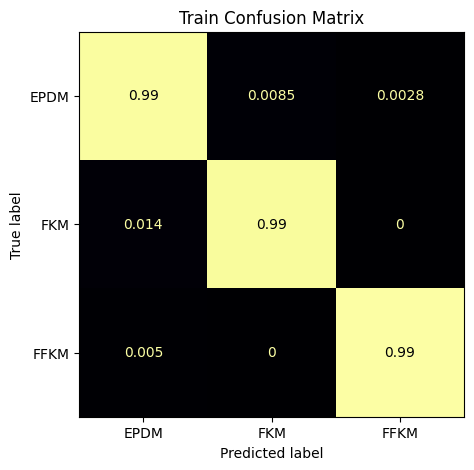

In [18]:
fig, ax = plt.subplots(1, 1, figsize=[5, 5])

disp = sklearn.metrics.ConfusionMatrixDisplay(np.array([cm_train[0] / cm_train[0].sum(), 
                                                        cm_train[1] / cm_train[1].sum(), 
                                                        cm_train[2] / cm_train[2].sum()]), 
                                              display_labels=['EPDM', 'FKM', 'FFKM'])

ax.set_title('Train Confusion Matrix')
disp.plot(cmap='inferno', ax=ax, colorbar=False) # cmap: https://matplotlib.org/stable/tutorials/colors/colormaps.html
plt.show()

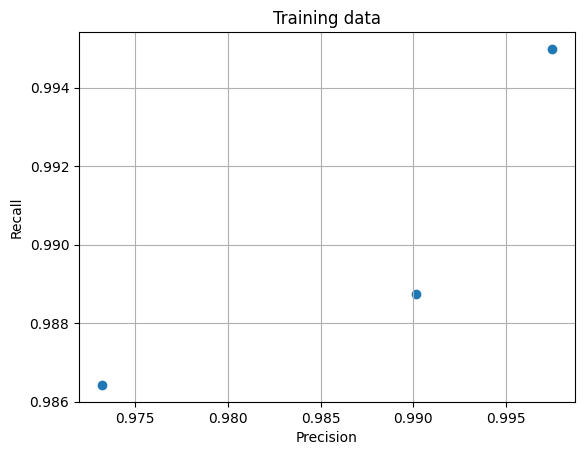

In [19]:
fig, ax = plt.subplots(1, 1)#, figsize=[5, 5])
n = ['EPDM\n'+str(round(precision_score_train_None[0],3))+'\n'+str(round(recall_score_train_None[0],3)),
     'FKM\n'+str(round(precision_score_train_None[1],3))+'\n'+str(round(recall_score_train_None[1],3)), 
     'FFKM\n'+str(round(precision_score_train_None[2],3))+'\n'+str(round(recall_score_train_None[2],3))]

ax.scatter(precision_score_train_None, recall_score_train_None)
ax.grid()
ax.set_xlabel('Precision')
ax.set_ylabel('Recall')
ax.set_title('Training data')

ax.annotate(n[0], (precision_score_train_None[0]+0.0015, recall_score_train_None[0]-0.009)) # EPDM
ax.annotate(n[1], (precision_score_train_None[1]+0.0015, recall_score_train_None[1]-0.003)) # FKM
ax.annotate(n[2], (precision_score_train_None[2]-0.008, recall_score_train_None[2]-0.011)) # FFKM
plt.show()

## Test model

In [20]:
y_predict = model(torch.tensor(X_test,dtype=torch.float32)).detach().numpy()
y_predict

array([[9.99999762e-01, 3.53938567e-09, 2.03294420e-07],
       [9.99878407e-01, 1.03871585e-04, 1.78176779e-05],
       [1.03688857e-03, 2.25297743e-04, 9.98737872e-01],
       ...,
       [1.63922695e-10, 1.75947698e-05, 9.99982357e-01],
       [3.83036677e-05, 9.99958873e-01, 2.81032499e-06],
       [1.90910043e-09, 1.94802749e-04, 9.99805272e-01]], dtype=float32)

### Test metrics

In [21]:
new = np.zeros(y_predict.shape)
for i, j in enumerate(y_predict): # enumerate, itterieren durch Liste i = index, j = Wert
    new[i][np.argmax(j)] = 1

y_predict_class = new.astype('int')
y_predict_class

array([[1, 0, 0],
       [1, 0, 0],
       [0, 0, 1],
       ...,
       [0, 0, 1],
       [0, 1, 0],
       [0, 0, 1]])

In [22]:
# Calculate scores
r2_score_test = sklearn.metrics.r2_score(y_test, y_predict_class)
ev_score_test = sklearn.metrics.explained_variance_score(y_test, y_predict_class)
mse_test = sklearn.metrics.mean_squared_error(y_test, y_predict_class)
acc_score_test = sklearn.metrics.accuracy_score(y_test, y_predict_class)
precision_score_test_None = sklearn.metrics.precision_score(y_test, y_predict_class, average=None)
recall_score_test_None = sklearn.metrics.recall_score(y_test, y_predict_class, average=None)
precision_score_test_macro = sklearn.metrics.precision_score(y_test, y_predict_class, average='macro')
recall_score_test_macro= sklearn.metrics.recall_score(y_test, y_predict_class, average='macro')

print("R2 Score: {:.4f}".format(r2_score_train))
print("Explained variance score: {:.4f}".format(ev_score_train))
print("Mean squared error: {:.4f}".format(mse_train))
print("Accuracy Score: {:.4f}".format(acc_score_test))
print(f"Precision: {np.array2string(precision_score_test_None, precision=4, floatmode='fixed')}")
print(f"Recall: {np.array2string(recall_score_test_None, precision=4, floatmode='fixed')}")
print(f"Precision macro: {precision_score_test_macro}")
print(f"Recall macro: {recall_score_test_macro}")

R2 Score: 0.9678
Explained variance score: 0.9678
Mean squared error: 0.0058
Accuracy Score: 0.9885
Precision: [1.0000 0.9000 1.0000]
Recall: [0.9721 1.0000 1.0000]
Precision macro: 0.9666666666666667
Recall macro: 0.9906890130353817


### Test quality

In [23]:
class_number = len(y_predict_class[0])
cm_test = np.zeros((class_number, class_number))
for tr, pre in zip(y_test, y_predict_class):
    i_true = np.argmax(tr)
    i_pred = np.argmax(pre)
    cm_test[i_true][i_pred] += 1
    
cm_test

array([[174.,   5.,   0.],
       [  0.,  45.,   0.],
       [  0.,   0., 209.]])

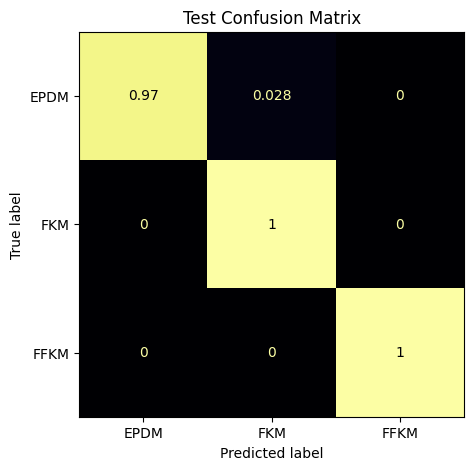

In [24]:
# sklearn.metrics.ConfusionMatrixDisplay(cm_train).plot()
fig, ax = plt.subplots(1, 1, figsize=[5, 5])

disp = sklearn.metrics.ConfusionMatrixDisplay(np.array([cm_test[0] / cm_test[0].sum(), 
                                                 cm_test[1] / cm_test[1].sum(), 
                                                 cm_test[2] / cm_test[2].sum()]),
                                              display_labels=['EPDM', 'FKM', 'FFKM'])

ax.set_title('Test Confusion Matrix')
disp.plot(cmap='inferno', ax=ax, colorbar=False) # cmap: https://matplotlib.org/stable/tutorials/colors/colormaps.html
plt.show()

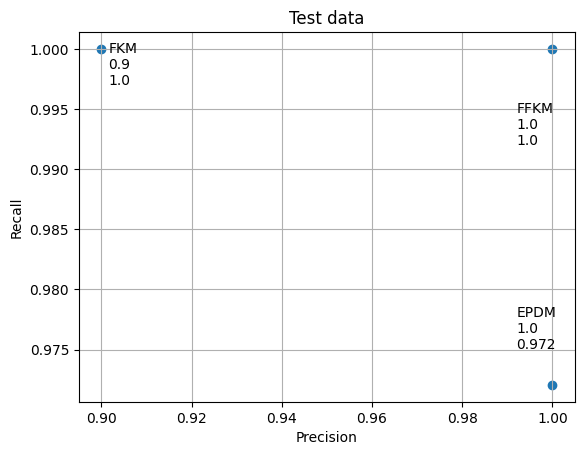

In [25]:
fig, ax = plt.subplots(1, 1)#, figsize=[5, 5])
n = ['EPDM\n'+str(round(precision_score_test_None[0],3))+'\n'+str(round(recall_score_test_None[0],3)),
     'FKM\n'+str(round(precision_score_test_None[1],3))+'\n'+str(round(recall_score_test_None[1],3)), 
     'FFKM\n'+str(round(precision_score_test_None[2],3))+'\n'+str(round(recall_score_test_None[2],3))]

ax.scatter(precision_score_test_None, recall_score_test_None)
ax.grid()
ax.set_xlabel('Precision')
ax.set_ylabel('Recall')
ax.set_title('Test data')

ax.annotate(n[0], (precision_score_test_None[0]-0.008, recall_score_test_None[0]+0.003)) # EPDM
ax.annotate(n[1], (precision_score_test_None[1]+0.0015, recall_score_test_None[1]-0.003)) # FKM
ax.annotate(n[2], (precision_score_test_None[2]-0.008, recall_score_test_None[2]-0.008)) # FFKM
plt.show()

In [27]:
# torch.save(deepcopy(model.state_dict()), 'ValvePositionModel.pt')